# Ruido Marginal respecto a q

In [17]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

# Variables simbolicas
q = sp.symbols('q', positive=True)   # flujo
vf = sp.symbols('vf', positive=True) # velocidad libre
qmax = sp.symbols('qmax', positive=True) # flujo máximo
kj = sp.symbols('kj', positive=True) # densidad de atasco
c = sp.symbols('c', positive=True)   # constante del modelo

def L_q(vq):
    """ Retorna L(q) = 10*log10(q/v(q)) """
    return 10*sp.log(q/vq, 10)

def v_greenberg(q, c=25, kj=150, max_iter=100, tol=1e-6):
    """
    Resuelve v(q) para el modelo Greenberg mediante fixed-point iteration.
    v = c * ln(kj * v / q)
    """
    v = c  # estimación inicial
    for _ in range(max_iter):
        v_new = c * np.log((kj * v) / q)
        if np.isnan(v_new) or v_new <= 0:
            return np.nan
        if abs(v_new - v) < tol:
            return v_new
        v = v_new
    return np.nan

def L_greenberg(q, c=25, kj=150):
    v = v_greenberg(q, c, kj)
    return 10 * np.log10(q / v)

def RM_greenberg(q, c=25, kj=150, h=1e-3):
    return (L_greenberg(q+h, c, kj) - L_greenberg(q-h, c, kj)) / (2*h)


In [18]:
#derivada respecto a q segun V = Greenshields (lineal)
v_greenshields = vf * (1 - q/qmax)

L_g = L_q(v_greenshields)
RM_g = sp.diff(L_g, q)   # derivada
RM_g

10*vf*(-q/qmax + 1)*(q/(qmax*vf*(-q/qmax + 1)**2) + 1/(vf*(-q/qmax + 1)))/(q*log(10))

In [19]:
#derivada respecto a q segun V = Greenberg (logaritmica)
# v = c * ln(kj/k) = c * ln(kj * v / q)
v = sp.Function('v')

eq_greenberg = sp.Eq(v(q), c * sp.log(kj * v(q) / q))

# Resolver v(q)
v_greenberg_sympy_expr = sp.solve(eq_greenberg, v(q))[0]

v_greenberg_sympy_expr

L_gr = L_q(v_greenberg_sympy_expr)
RM_gr = sp.diff(L_gr, q)
RM_gr

-10*c*(-1/(c*LambertW(-q/(c*kj))) + 1/(c*(LambertW(-q/(c*kj)) + 1)*LambertW(-q/(c*kj))))*LambertW(-q/(c*kj))/(q*log(10))

In [20]:
#derivada respecto a q segun V = Drake (exponencial)
eq_drake = sp.Eq(v(q), vf * sp.exp(-(q / (kj * v(q)))))

"""
#resolver
v_drake = sp.solve(eq_drake, v(q))[0]

v_drake

L_d = L_q(v_drake)
RM_d = sp.diff(L_d, q)
RM_d
#implicito y tengo v(q) dentro del exp, por lo que no se puede resolver implicitamente
"""
#Simpy no puede resolver Drake, dara error, ya que v(q) aparece tanto de
#forma explícita como dentro de una función exponencial, lo que la convierte
#en una ecuación trascendental implícita para la cual no existen algoritmos
#de solución directa implementados en SymPy

'\n#resolver\nv_drake = sp.solve(eq_drake, v(q))[0]\n\nv_drake\n\nL_d = L_q(v_drake)\nRM_d = sp.diff(L_d, q)\nRM_d\n#implicito y tengo v(q) dentro del exp, por lo que no se puede resolver implicitamente\n'

In [21]:
#Drake resuelto con metodos numericos
#solver iterativo tipo Newton Rashford
def v_drake(q, vf=80, kj=150, max_iter=100, tol=1e-6):
    """
    Resuelve v(q) para el modelo de Drake de manera iterativa.
    v = vf * exp( - q / (kj * v) )
    """
    v = vf
    for i in range(max_iter):
        v_new = vf * np.exp(- q / (kj * v))
        if abs(v_new - v) < tol:
            return v_new
        v = v_new
    return v

#ruido basado V de Drake
def L_drake(q, vf=80, kj=150):
    v = v_drake(q, vf, kj)
    return 10 * np.log10(q / v)

#derivada numerica
def RM_drake(q, vf=80, kj=150, h=1e-3):
    return (L_drake(q+h, vf, kj) - L_drake(q-h, vf, kj)) / (2*h)

In [22]:
#conversion de expresiones en funciones numericas para numpy
RM_g_f = sp.lambdify((q, vf, qmax), RM_g, 'numpy')
#RM_gr_f = sp.lambdify((q, c, kj), RM_gr, 'numpy')
#RM_d_f = sp.lambdify((q, vf, kj), RM_d, 'numpy')

<lambdifygenerated-7>:2: RuntimeWarning: divide by zero encountered in divide
  return 10*vf*(-q/qmax + 1)*(q/(qmax*vf*(-q/qmax + 1)**2) + 1/(vf*(-q/qmax + 1)))/(q*log(10))
<lambdifygenerated-7>:2: RuntimeWarning: invalid value encountered in multiply
  return 10*vf*(-q/qmax + 1)*(q/(qmax*vf*(-q/qmax + 1)**2) + 1/(vf*(-q/qmax + 1)))/(q*log(10))


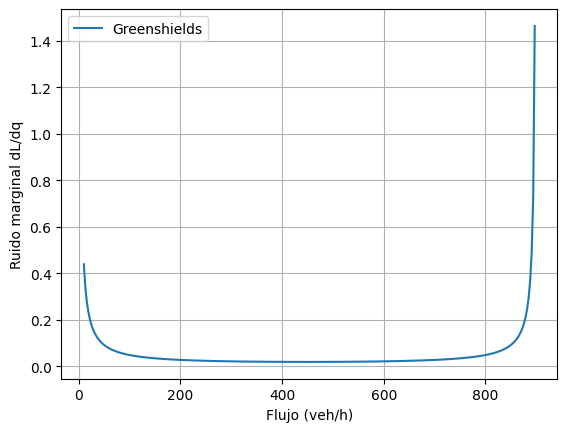

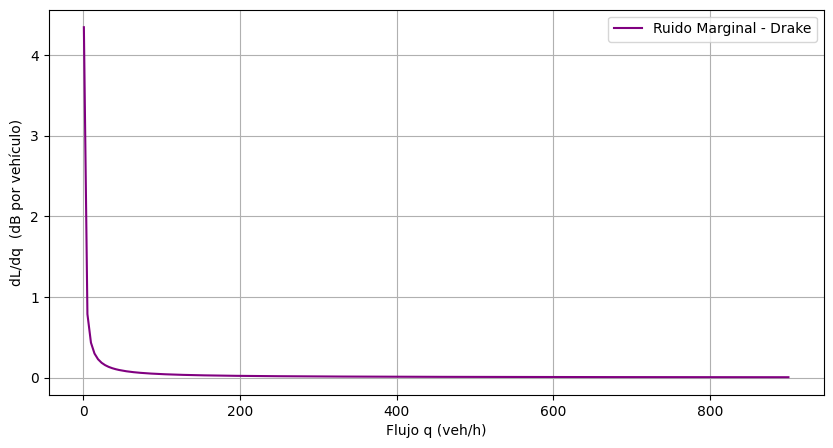

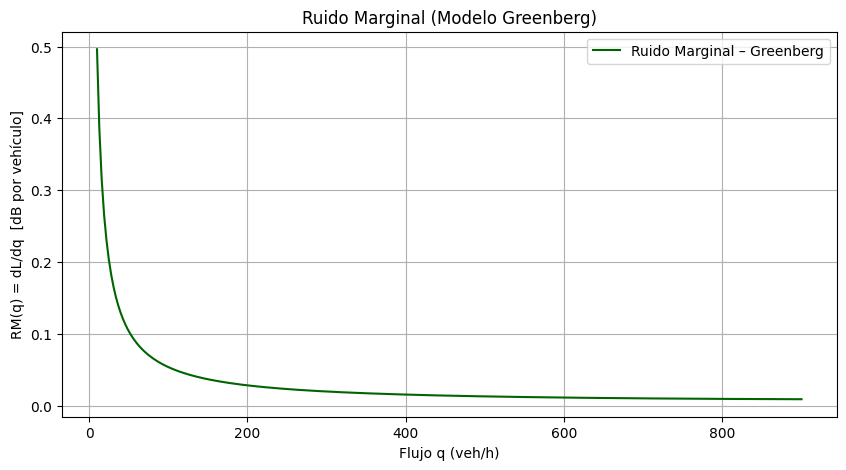

In [23]:
#grafico Greenshields
qs = np.linspace(10, 900, 300)

rm_g_vals = RM_g_f(qs, 80, 900)
plt.plot(qs, rm_g_vals, label="Greenshields")

plt.legend()
plt.xlabel("Flujo (veh/h)")
plt.ylabel("Ruido marginal dL/dq")
plt.grid()
plt.show()

#grafico Drake
qs = np.linspace(1, 900, 200)
rm_vals = np.array([RM_drake(q) for q in qs])

plt.figure(figsize=(10,5))
plt.plot(qs, rm_vals, label="Ruido Marginal - Drake", color='purple')
plt.xlabel("Flujo q (veh/h)")
plt.ylabel("dL/dq  (dB por vehículo)")
plt.grid()
plt.legend()
plt.show()

# Redefinir las funciones necesarias para Greenberg para asegurar su visibilidad
def v_greenberg_numerical(q, c=25, kj=150, max_iter=100, tol=1e-6):
    """
    Resuelve redefine para evitar transformaciones de Simpy previas.
    v = c * ln(kj * v / q)
    """
    v = c  # estimación inicial
    for _ in range(max_iter):
        # numpy.log (logaritmo natural)
        # sympy.log (logaritmo natural por defecto, log10 si se especifica base)
        v_new = c * np.log((kj * v) / q)
        if np.isnan(v_new) or v_new <= 0:
            return np.nan
        if abs(v_new - v) < tol:
            return v_new
        v = v_new
    return np.nan

def L_greenberg_numerical(q, c=25, kj=150):
    v = v_greenberg_numerical(q, c, kj)
    # numpy.log10 (logaritmo base 10)
    return 10 * np.log10(q / v)

def RM_greenberg_numerical(q, c=25, kj=150, h=1e-3):
    return (L_greenberg_numerical(q+h, c, kj) - L_greenberg_numerical(q-h, c, kj)) / (2*h)

#grafico Greenbrg
qs = np.linspace(10, 900, 300)  # flujos entre 10 y 900 veh/h
rm_vals = np.array([RM_greenberg_numerical(q) for q in qs])

plt.figure(figsize=(10,5))
plt.plot(qs, rm_vals, label="Ruido Marginal – Greenberg", color='darkgreen')
plt.xlabel("Flujo q (veh/h)")
plt.ylabel("RM(q) = dL/dq  [dB por vehículo]")
plt.title("Ruido Marginal (Modelo Greenberg)")
plt.grid()
plt.legend()
plt.show()

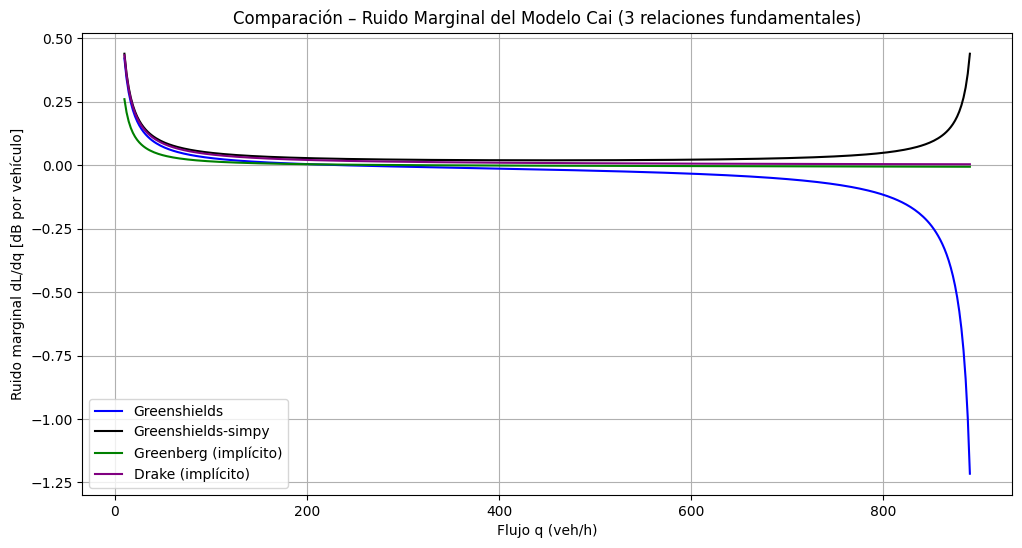

In [24]:
#implementacion RM a modelo Cai completo
def L0(v, tam="large"):
    v = np.maximum(v, 1e-6)
    if tam == "large":
        return 38.10 * np.log10(v) + 18.00
    elif tam == "medium":
        return 43.70 * np.log10(v) + 4.80
    else:
        return 33.66 * np.log10(v) + 12.60

def T_q(q, v):
    return 10 * np.log10(q / v)

def k_greenshields(q, vf=80, qmax=900):
    v = v_greenshields(q, vf, qmax)
    return q / v  # densidad física correcta

def T_q_greenshields(q, vf=80, qmax=900):
    k = k_greenshields(q, vf, qmax)
    return 10 * np.log10(k)

def A_geom(r=10.0, r0=1.0, alpha=0.0):
    return 10 * np.log10((r0 / r)**(1 + alpha))

def L_cai_total(q, v, r, tam="large", C0=0):
    return L0(v, tam) + T_q(q, v) + A_geom(r) + C0

def L_cai_total_gre(q, v, r, tam="large", C0=0, vf=80, qmax=900):
    return (L0(v, tam)
            + T_q_greenshields(q, vf, qmax)  # término correcto
            + A_geom(r)
            + C0)

def v_greenshields(q, vf=80, qmax=900):
    v = vf * (1 - q/qmax)
    return np.maximum(v, 1e-6)

def v_greenberg(q, c=25, kj=150, max_iter=200, tol=1e-6):
    v = c  # inicialización razonable
    for _ in range(max_iter):
        v_new = c * np.log((kj * v) / q)
        if np.isnan(v_new) or v_new <= 0:
            return np.nan
        if abs(v_new - v) < tol:
            return v_new
        v = v_new
    return np.nan

def v_drake(q, vf=80, kj=150, max_iter=200, tol=1e-6):
    v = vf
    for _ in range(max_iter):
        v_new = vf * np.exp(-(q/(kj * v)))
        if np.isnan(v_new) or v_new <= 0:
            return np.nan
        if abs(v_new - v) < tol:
            return v_new
        v = v_new
    return v

def RM_cai(q, v_func, r=10, tam="large", C0=0, h=1e-3):
    v_plus = v_func(q + h)
    v_minus = v_func(q - h)

    if np.isnan(v_plus) or np.isnan(v_minus):
        return np.nan

    L_plus = L_cai_total(q + h, v_plus, r, tam, C0)
    L_minus = L_cai_total(q - h, v_minus, r, tam, C0)

    return (L_plus - L_minus) / (2*h)

def RM_cai_greenshields(q, r=10, tam="large", C0=0, h=1e-3, vf=80, qmax=900):
    v_plus = v_greenshields(q + h, vf, qmax)
    v_minus = v_greenshields(q - h, vf, qmax)

    L_plus = L_cai_total_gre(q + h, v_plus, r, tam, C0, vf, qmax)
    L_minus = L_cai_total_gre(q - h, v_minus, r, tam, C0, vf, qmax)

    return (L_plus - L_minus) / (2*h)


qs = np.linspace(10, 890, 400)

RM_gre = np.array([RM_cai_greenshields(q) for q in qs])
RM_gre_solve_f = sp.lambdify((q, vf, qmax), RM_g, 'numpy')
RM_gre_solve = RM_gre_solve_f(qs, 80, 900)
RM_grb = np.array([RM_cai(q, v_greenberg) for q in qs])
RM_drk = np.array([RM_cai(q, v_drake) for q in qs])

plt.figure(figsize=(12,6))
plt.plot(qs, RM_gre, label="Greenshields", color='blue')
plt.plot(qs, RM_gre_solve, label="Greenshields-simpy", color='black')
plt.plot(qs, RM_grb, label="Greenberg (implícito)", color='green')
plt.plot(qs, RM_drk, label="Drake (implícito)", color='purple')

plt.xlabel("Flujo q (veh/h)")
plt.ylabel("Ruido marginal dL/dq [dB por vehículo]")
plt.title("Comparación – Ruido Marginal del Modelo Cai (3 relaciones fundamentales)")
plt.grid()
plt.legend()
plt.show()


# Ruido Marginal respecto a k

In [25]:
#dependencias
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

In [26]:
#derivada Simpy

#simbolos
k, vf, kj, r, r0, alpha = sp.symbols('k vf kj r r0 alpha', positive=True, real=True)
a, b = sp.symbols('a b', real=True)
c, DeltaL = sp.symbols('C DeltaL', real=True)  #constante

#v(k) Greenshields
v_k = vf * (1 - k/kj)

#helper log10
log10 = lambda x: sp.log(x, 10)

#Modelo Cai respecto k
geom_inner_ln = sp.log((r0/r)**(1 + alpha))
geom_term = 10 * log10(sp.Abs(geom_inner_ln))
L_k = a*log10(v_k) + b + 10*log10(k) + geom_term + 10*log10(sp.pi*r0) + DeltaL

#derivada
dL_dk = sp.diff(L_k, k)
dL_dk_simpl = sp.simplify(dL_dk)

print("L(k) =")
sp.pprint(L_k)
print("\ndL/dk =")
sp.pprint(dL_dk_simpl)

L(k) =
                                                                     ⎛│   ⎛    ↪
              ⎛   ⎛  k     ⎞⎞                                        ⎜│   ⎜⎛r₀ ↪
         a⋅log⎜vf⋅⎜- ── + 1⎟⎟                                  10⋅log⎜│log⎜⎜── ↪
              ⎝   ⎝  kj    ⎠⎠       10⋅log(k)   10⋅log(π⋅r₀)         ⎝│   ⎝⎝r  ↪
DeltaL + ──────────────────── + b + ───────── + ──────────── + ─────────────── ↪
               log(10)               log(10)      log(10)              log(10) ↪

↪  α + 1⎞│⎞
↪ ⎞     ⎟│⎟
↪ ⎟     ⎟│⎟
↪ ⎠     ⎠│⎠
↪ ─────────
↪          

dL/dk =
a⋅k + 10⋅k - 10⋅kj
──────────────────
k⋅(k - kj)⋅log(10)


In [27]:
#funciones
def a_tam(tam="large"):
    if tam == "large":
        return 38.10
    elif tam == "medium":
        return 43.70
    else:
        return 33.66

def L0(v, tam="large"):
    v = np.maximum(v, 1e-12)
    a = a_tam(tam)
    if tam == "large":
        return a * np.log10(v) + 18.00
    elif tam == "medium":
        return a * np.log10(v) + 4.80
    else:
        return a * np.log10(v) + 12.60

# Geometria difractora (constante respecto a k)
def A_geom(r=10.0, r0=1.0, alpha=0.0):
    return 10 * np.log10((r0 / r)**(1 + alpha))

# Ruido (Cai, 2014) total funcion de k
def L_cai_total_k(k, vf=80.0, kj=150.0, r=10.0, r0=1.0, alpha=0.0, tam="large", C0=0.0):
    k = np.maximum(k, 1e-12)
    v = v_greenshields_k(k, vf=vf, kj=kj)
    term_trafico = 10.0 * np.log10(k)
    inner_ln = np.log((r0 / r) ** (1.0 + alpha))
    term_geom = 10.0 * np.log10(np.maximum(np.abs(inner_ln), 1e-12))
    term_const = 10.0 * np.log10(np.pi * r0)

    return L0(v, tam) + term_trafico + term_geom + term_const + C0

#Ruido marginal analitico dL/dk
def RMk_cai_greenshields_analytic(k, vf=80.0, kj=150.0, tam="large"):
    k = np.asarray(k, dtype=float)
    k = np.maximum(k, 1e-12)

    v = v_greenshields_k(k, vf=vf, kj=kj)
    dv_dk = -vf / kj
    a = a_tam(tam)
    ln10 = np.log(10.0)
    term_vel = (a / ln10) * (dv_dk / v)
    term_k = (10.0 / ln10) * (1.0 / k)

    return term_vel + term_k

# dL/dk numerico - manual (validacion)
def RMk_cai_numeric(k, vf=80.0, kj=150.0, r=10.0, tam="large", C0=0.0, h=1e-4):
    k = float(k)
    Lp = L_cai_total_k(k + h, vf=vf, kj=kj, r=r, tam=tam, C0=C0)
    Lm = L_cai_total_k(k - h, vf=vf, kj=kj, r=r, tam=tam, C0=C0)
    return (Lp - Lm) / (2*h)

#v(k)
def v_greenshields_k(k, vf=80.0, kj=150.0):
    k = np.asarray(k, dtype=float)
    v = vf * (1.0 - k / kj)
    return np.maximum(v, 1e-12)

def v_greenberg_k(k, c=c, kj=kj):
    return c * np.log(kj / k)

def v_drake_k(k, vf=vf, kj=kj):
    return vf * np.exp(-k/kj)

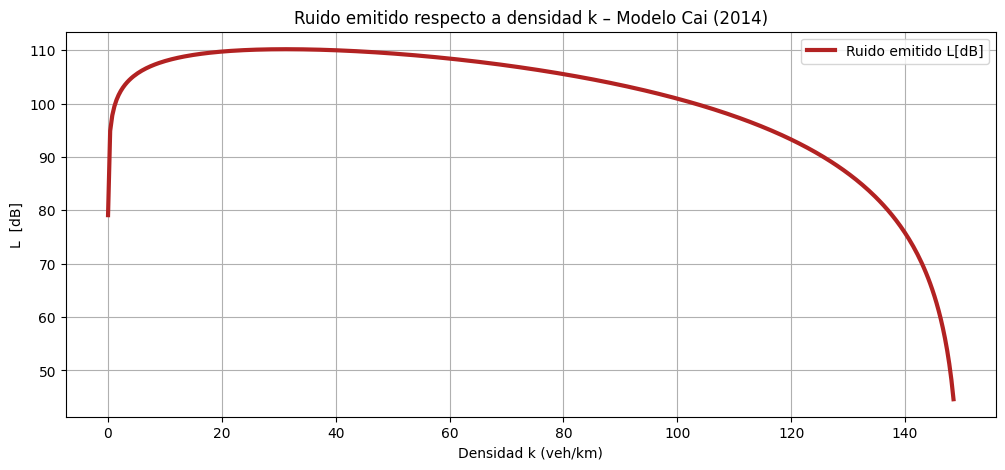

In [28]:
#Grafico Ruido emitido vs densidad k
vf_val = 80.0
kj_val = 150.0
a_val = a_tam()

ks = np.linspace(0.01, 0.99*kj_val, 400)  # evita k=0 y k=kj

y = L_cai_total_k(ks, vf_val, kj_val)
plt.figure(figsize=(12,5))
plt.plot(ks, y, label="Ruido emitido L[dB]", color="firebrick", linewidth=3)
plt.xlabel("Densidad k (veh/km)")
plt.ylabel("L  [dB]")
plt.title("Ruido emitido respecto a densidad k – Modelo Cai (2014)")
plt.grid(True)
plt.legend()
plt.show()

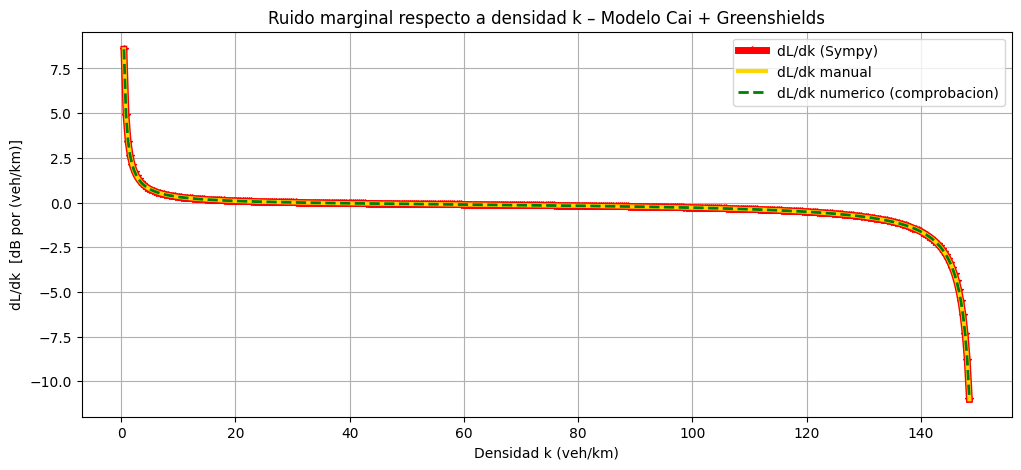

In [29]:
#Grafico RM vs k - greenshields con dif metodologias de diferencial
vf_val = 80.0
kj_val = 150.0
a_val = a_tam()

ks = np.linspace(0.5, 0.99*kj_val, 400)  # evita k=0 y k=kj

dLdk_f = sp.lambdify((k, vf, kj, a), dL_dk_simpl, "numpy")
rmk_sym = dLdk_f(ks, vf_val, kj_val, a_tam())
RMk_ana = RMk_cai_greenshields_analytic(ks, vf=vf_val, kj=kj_val, tam="large")
RMk_num = np.array([RMk_cai_numeric(k, vf=vf_val, kj=kj_val, tam="large") for k in ks])

plt.figure(figsize=(12,5))
plt.plot(ks, rmk_sym, label="dL/dk (Sympy)", marker="*", color="red", linewidth=5)
plt.plot(ks, RMk_ana, label="dL/dk manual", color="gold", linewidth=3)
plt.plot(ks, RMk_num, "--", label="dL/dk numerico (comprobacion)", color="green", linewidth=2)
plt.xlabel("Densidad k (veh/km)")
plt.ylabel("dL/dk  [dB por (veh/km)]")
plt.title("Ruido marginal respecto a densidad k – Modelo Cai + Greenshields")
plt.grid(True)
plt.legend()
plt.show()

# Comparacion de modelos fundamentales (Greenshields, Greenberg y Drake)

In [30]:
# simbolos
k, vf, kj, c = sp.symbols('k vf kj c', positive=True, real=True)
a, b, C = sp.symbols('a b C', real=True)

log10 = lambda x: sp.log(x, 10)

#v(k) por modelo fundamental
v_gre = vf*(1 - k/kj)
v_grb = c*sp.log(kj/k)
v_drk = vf*sp.exp(-k/kj)

#L(k) (Cai respecto k)
def L_of_v(vk):
    return a*log10(vk) + b + 10*log10(k) + C

L_gre = L_of_v(v_gre)
L_grb = L_of_v(v_grb)
L_drk = L_of_v(v_drk)

#Derivar dL/dk y simplificar
dLdk_gre = sp.simplify(sp.diff(L_gre, k))
dLdk_grb = sp.simplify(sp.diff(L_grb, k))
dLdk_drk = sp.simplify(sp.diff(L_drk, k))

print("dL/dk Greenshields:")
sp.pprint(dLdk_gre)
print("\ndL/dk Greenberg:")
sp.pprint(dLdk_grb)
print("\ndL/dk Drake:")
sp.pprint(dLdk_drk)

dL/dk Greenshields:
a⋅k + 10⋅k - 10⋅kj
──────────────────
k⋅(k - kj)⋅log(10)

dL/dk Greenberg:
         ⎛  10⎞  
         ⎜kj  ⎟  
 -a + log⎜────⎟  
         ⎜ 10 ⎟  
         ⎝k   ⎠  
─────────────────
             ⎛kj⎞
k⋅log(10)⋅log⎜──⎟
             ⎝k ⎠

dL/dk Drake:
-a⋅k + 10⋅kj
────────────
k⋅kj⋅log(10)


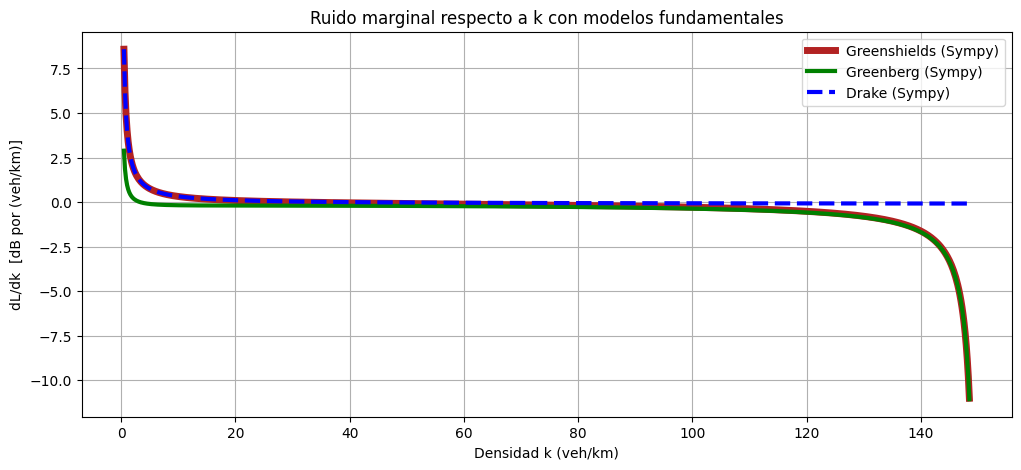

In [31]:
#graficar RM vs k con modelos fundamentales
dLdk_gre_f = sp.lambdify((k, vf, kj, a), dLdk_gre, "numpy")
dLdk_grb_f = sp.lambdify((k, c, kj, a),  dLdk_grb, "numpy")
dLdk_drk_f = sp.lambdify((k, vf, kj, a), dLdk_drk, "numpy")

# Parametros numericos
vf_val = 80.0
kj_val = 150.0
c_val  = 25.0
a_val  = 38.10  #"large"

#Dominio
ks = np.linspace(0.5, 0.99*kj_val, 800)

#var_dependiente (dL/dk)
rmk_gre = dLdk_gre_f(ks, vf_val, kj_val, a_val)
rmk_grb = dLdk_grb_f(ks, c_val,  kj_val, a_val)
rmk_drk = dLdk_drk_f(ks, vf_val, kj_val, a_val)

plt.figure(figsize=(12,5))
plt.plot(ks, rmk_gre, label="Greenshields (Sympy)", linewidth=5, color="firebrick")
plt.plot(ks, rmk_grb, label="Greenberg (Sympy)",linewidth=3, color="green")
plt.plot(ks, rmk_drk, "--" ,label="Drake (Sympy)", linewidth=3, color="blue")
plt.xlabel("Densidad k (veh/km)")
plt.ylabel("dL/dk  [dB por (veh/km)]")
plt.title("Ruido marginal respecto a k con modelos fundamentales")
plt.grid(True)
plt.legend()
plt.show()

### Graficos Velocidades x Modelos de trafico

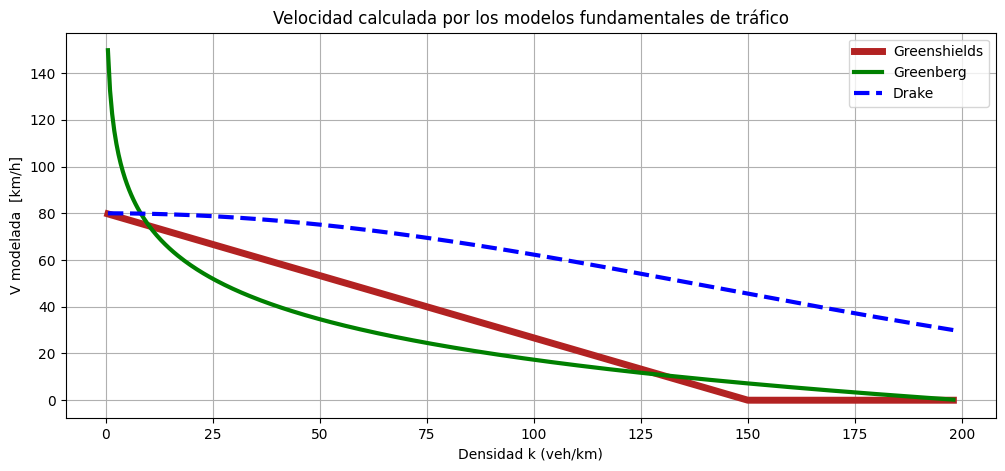

In [32]:
vf_val = 80.0
kj_val = 200.0
a_val = a_tam()

ks = np.linspace(0.5, 0.99*kj_val, 400)  # evita k=0 y k=kj

def v_greenshields_k(k, vf=80.0, kj=150.0):
    k = np.asarray(k, dtype=float)
    v = vf * (1.0 - k / kj)
    return np.maximum(v, 1e-12)

def v_greenberg_k(k, c=c_val, kj=kj_val):
    return c * np.log(kj / k)

def v_drake_k(k, vf=vf_val, kj=kj_val):
    return vf * np.exp(-(k/kj)**2)

v_gre = v_greenshields_k(ks)
v_gr = v_greenberg_k(ks)
v_drk = v_drake_k(ks)

plt.figure(figsize=(12,5))
plt.plot(ks, v_gre, label="Greenshields", linewidth=5, color="firebrick")
plt.plot(ks, v_gr, label="Greenberg",linewidth=3, color="green")
plt.plot(ks, v_drk, "--" ,label="Drake", linewidth=3, color="blue")
plt.xlabel("Densidad k (veh/km)")
plt.ylabel("V modelada  [km/h]")
plt.title("Velocidad calculada por los modelos fundamentales de tráfico")
plt.grid(True)
plt.legend()
plt.show()